In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# display settings
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 7043 rows, 21 columns


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 📋 Day 1: Initial Observations

- **Dataset:** 7,043 customers, 21 features
- **Target variable:** Churn (Yes/No)
- **Data types issue:** TotalCharges is `str` (should be `float64`) — blank spaces present
- **Missing values:** 0 detected via `isnull()`, but TotalCharges has hidden blank strings
- **SeniorCitizen:** 16.2% are senior citizens (binary: 0/1)
- **Tenure:** Ranges from 0 to 72 months (avg: 32.4 months)
- **MonthlyCharges:** Ranges from $18.25 to $118.75 (avg: $64.76)
- **Key categorical columns:** gender, Partner, Dependents, PhoneService, InternetService, Contract, PaymentMethod, etc.
  

In [11]:
# total charges ko numeric me convert krna
#error='coerce' matlab: jo convert nahi ho paaye, usse NaN (missing) banana

df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

# Ab check karo: kitne NaN ban gaye?

print('missing values in TotalCharges after converion:')
print(df['TotalCharges'].isnull().sum())

# Wo rows dekho jisme TotalCharges missing hai

print('\nRows with missing TotalCharges:')
df[df['TotalCharges'].isnull()]

missing values in TotalCharges after converion:
11

Rows with missing TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
# Missing TotalCharges ko fill karo: tenure * MonthlyCharges
# Logic: TotalCharges = kitne mahine × har mahine kitna charge

df['TotalCharges']=df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])
# Verify: ab koi missing nahi hona chahiye

print('Missing values after fix:')
print(df['TotalCharges'].isnull().sum())


Missing values after fix:
0


In [13]:
# ab check krna hai ki TotalCharges ka type theek hua?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
# now Kitne duplicate rows hain?
print(f'duplicate rows: {df.duplicated().sum()}')

# Agar duplicates hain toh hata do (abhi 0 hone chahiye)
df=df.drop_duplicates()
print(f'shape after removing duplicates: {df.shape}')

duplicate rows: 0
shape after removing duplicates: (7043, 21)


In [16]:
# Sirf numeric columns ke liye outliers check karo

numeric_cols=['tenure','MonthlyCharges','TotalCharges']
for col in numeric_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.25 * IQR
    upper_bound=Q3+1.25 * IQR
    outliers=df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col}: {len(outliers)} outliers')


tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 74 outliers


In [17]:
# TotalCharges ke outliers dekho

Q1=df[col].quantile(0.25)
Q2=df[col].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.25 * IQR
upper_bound=Q3+1.25 * IQR
# Upper outliers (high TotalCharges)

outliers = df[df['TotalCharges'] > upper_bound]
print(f"Upper bound: {upper_bound:.2f}")
print(f"\nOutliers ki tenure aur MonthlyCharges:")
print(outliers[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

Upper bound: 8021.66

Outliers ki tenure aur MonthlyCharges:
          tenure  MonthlyCharges  TotalCharges
count  74.000000       74.000000     74.000000
mean   71.675676      114.708784   8282.513514
std     0.760463        2.200115    176.105730
min    68.000000      109.250000   8022.850000
25%    72.000000      113.650000   8126.887500
50%    72.000000      115.100000   8293.350000
75%    72.000000      116.087500   8419.925000
max    72.000000      118.750000   8684.800000


In [19]:
# Clean data ko new CSV mein save karo

df.to_csv('data/cleaned_customer_churn.csv', index=False)
print('clean data saved')
print(f'final shape: {df.shape}')

clean data saved
final shape: (7043, 21)


In [20]:
# Final verify
print(" FINAL DATA QUALITY CHECK ")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

 FINAL DATA QUALITY CHECK 
Shape: (7043, 21)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies

## 🧹 Day 2: Data Cleaning

- **TotalCharges fixed:** Converted from `str` to `float64`
- **Missing values:** 11 blank strings found, filled using `tenure × MonthlyCharges`
- **Duplicates:** 0 duplicate rows found
- **Outliers:** 74 in TotalCharges, but all are valid long-tenure (avg 72 months), high-paying customers — retained
- **Final shape:** [output]
- **Clean data saved:** `cleaned_customer_churn.csv`

## 📊 Day 3: Exploratory Data Analysis

**Objective:** Data mein patterns dhoondhna — kaunse customers churn kar rahe hain?

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style set karo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Clean data load (agar df already memory mein hai toh zaroorat nahi)
# df = pd.read_csv('data/cleaned_customer_churn.csv')

Churn Rate (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


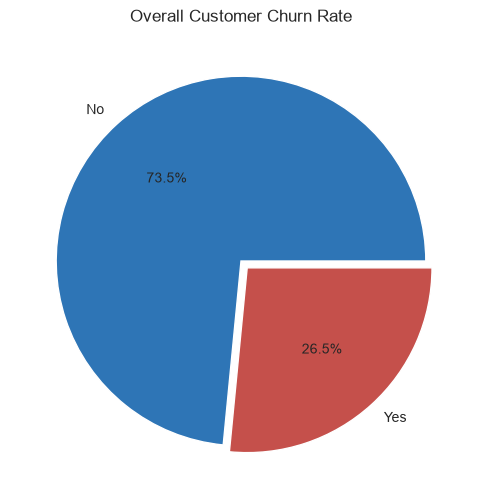

In [25]:
# Overall churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("Churn Rate (%):")
print(churn_rate.round(2))

# Pie chart
plt.figure(figsize=(6, 6))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                colors=['#2e75b6', '#c5504b'],
                                explode=(0, 0.05))
plt.title('Overall Customer Churn Rate')
plt.ylabel('')
plt.savefig('images/churn_pie.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
import os
os.makedirs('images', exist_ok=True)

Churn Rate by Contract Type (%):
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


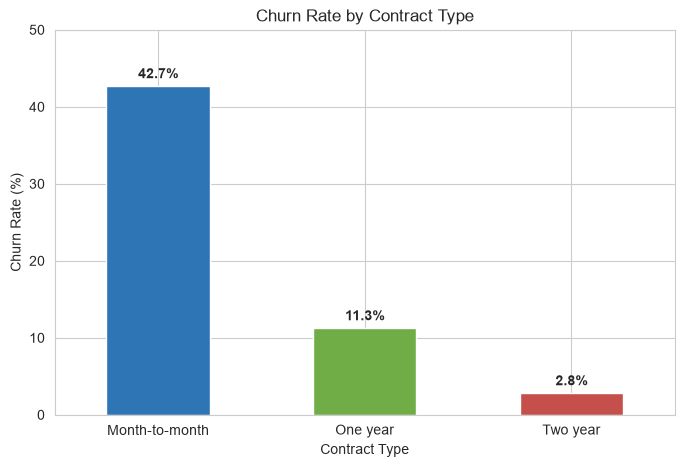

In [26]:
# Churn by Contract Type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print("Churn Rate by Contract Type (%):")
print(contract_churn.round(2))

# Bar chart
plt.figure(figsize=(8, 5))
contract_churn['Yes'].plot(kind='bar', color=['#2e75b6', '#70ad47', '#c5504b'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 50)

# Values upar likho
for i, v in enumerate(contract_churn['Yes']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.savefig('images/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

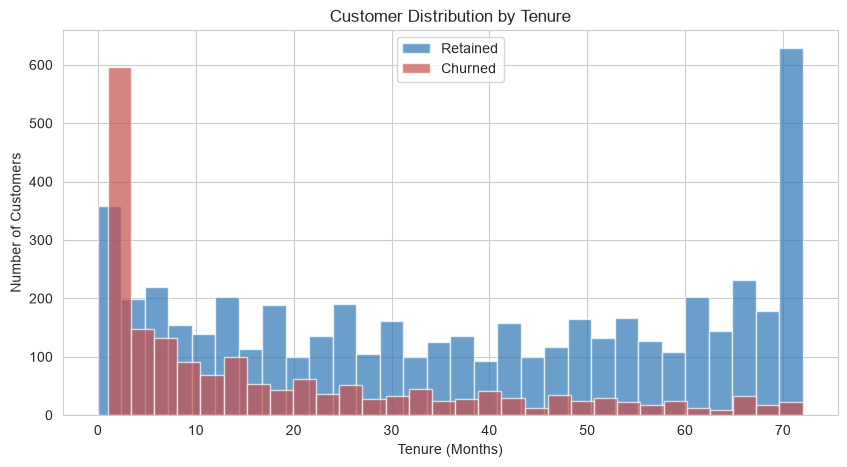


Average Tenure (Months):
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


In [27]:
# Churn by Tenure (kitne mahine rehke gaye)
plt.figure(figsize=(10, 5))

# Histogram: Churned vs Retained
df[df['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.7, label='Retained', color='#2e75b6')
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.7, label='Churned', color='#c5504b')

plt.title('Customer Distribution by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.savefig('images/churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

# Average tenure compare karo
avg_tenure = df.groupby('Churn')['tenure'].mean()
print("\nAverage Tenure (Months):")
print(avg_tenure.round(2))

/var/folders/ll/rvsj_xp55x5c7b116r7l_nkc0000gn/T/ipykernel_7508/3572985923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df,


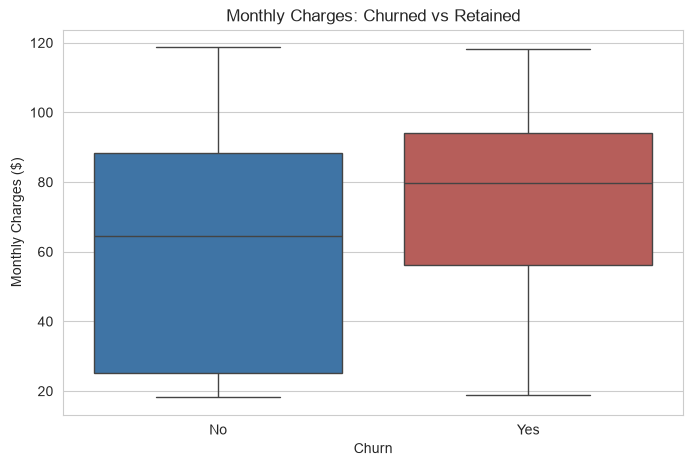


Average Monthly Charges ($):
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [28]:
# Churn by Monthly Charges (Box plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, 
            palette={'No': '#2e75b6', 'Yes': '#c5504b'})
plt.title('Monthly Charges: Churned vs Retained')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.savefig('images/churn_by_monthlycharges.png', dpi=150, bbox_inches='tight')
plt.show()

# Average compare karo
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print("\nAverage Monthly Charges ($):")
print(avg_charges.round(2))

Churn Rate by Internet Service (%):
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


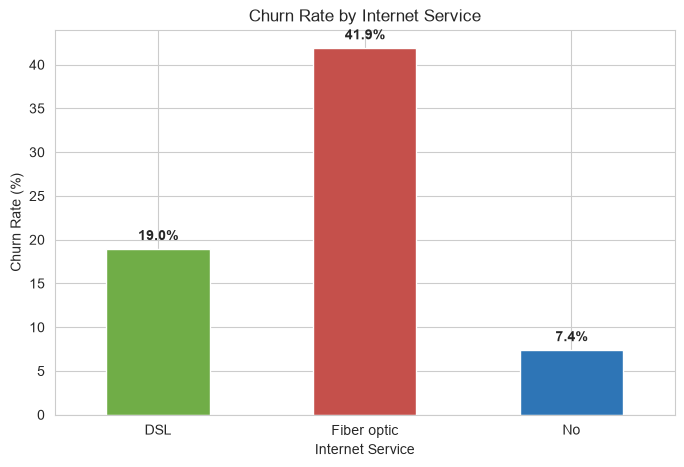

In [29]:
# Churn by Internet Service
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print("Churn Rate by Internet Service (%):")
print(internet_churn.round(2))

# Bar chart
plt.figure(figsize=(8, 5))
internet_churn['Yes'].plot(kind='bar', color=['#70ad47', '#c5504b', '#2e75b6'])
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(internet_churn['Yes']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.savefig('images/churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()

Churn Rate by Payment Method (%):
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


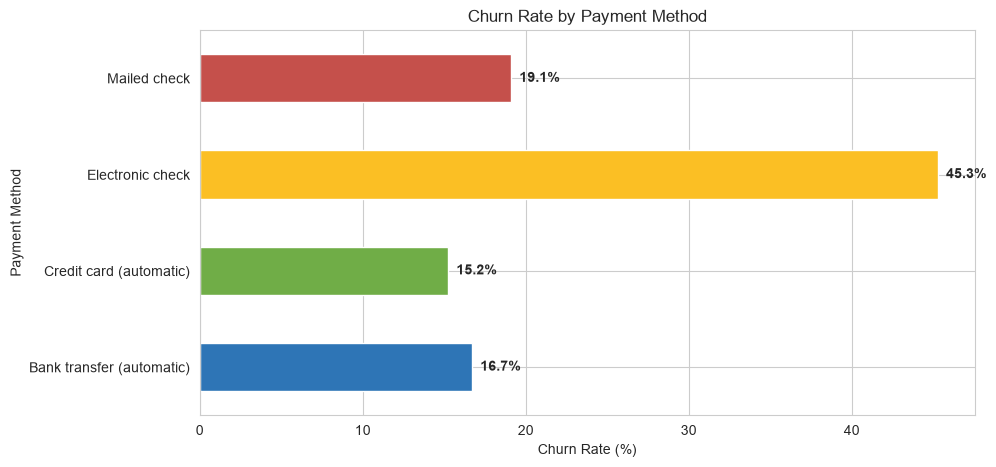

In [30]:
# Churn by Payment Method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
print("Churn Rate by Payment Method (%):")
print(payment_churn.round(2))

# Horizontal bar chart (names lambi hain)
plt.figure(figsize=(10, 5))
payment_churn['Yes'].plot(kind='barh', color=['#2e75b6', '#70ad47', '#fbbf24', '#c5504b'])
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')

for i, v in enumerate(payment_churn['Yes']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.savefig('images/churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Day 3: EDA Key Findings

### Overall Churn Rate: 26.54%

| Factor | Highest Churn | Lowest Churn | Insight |
|--------|--------------|-------------|---------|
| **Contract** | Month-to-month (42.71%) | Two year (2.83%) | Long-term contracts = retention |
| **Tenure** | Avg 17.98 months (churned) | Avg 37.57 months (retained) | New customers at risk |
| **Monthly Charges** | $74.44 (churned) | $61.27 (retained) | High price = dissatisfaction |
| **Internet Service** | Fiber optic (41.89%) | No internet (7.40%) | Fiber service issues |
| **Payment Method** | Electronic check (45.29%) | Credit card (15.24%) | Auto-pay = loyalty |

### 💡 Business Recommendations
1. **Push long-term contracts** — 15x churn reduction potential
2. **Investigate fiber optic service** — 42% churn is alarming
3. **Promote auto-pay enrollment** — 3x churn reduction potential
4. **Focus on new customer onboarding** — first 18 months critical

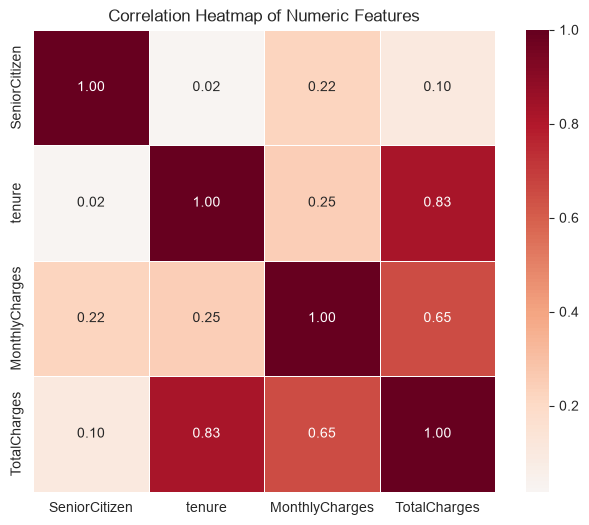

In [31]:
# Correlation Heatmap — numeric columns ke beech relation dekho
plt.figure(figsize=(8, 6))

# Sirf numeric columns lo
numeric_df = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']]

# Correlation matrix banao
corr = numeric_df.corr()

# Heatmap banao
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Churn Rate by Tenure Segment (%):
Churn                  No    Yes
TenureSegment                   
Loyal (37+ months)  88.07  11.93
Mid (13-36 months)  74.46  25.54
New (0-12 months)   52.56  47.44


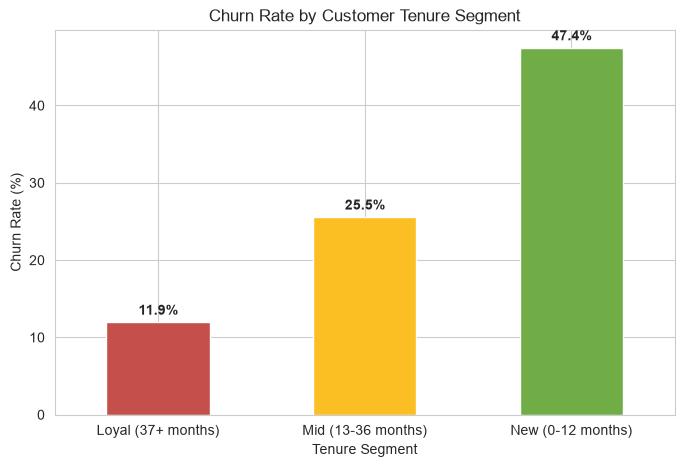

In [33]:
# Customers ko segments mein baanto
def tenure_segment(tenure):
    if tenure <= 12:
        return 'New (0-12 months)'
    elif tenure <= 36:
        return 'Mid (13-36 months)'
    else:
        return 'Loyal (37+ months)'

df['TenureSegment'] = df['tenure'].apply(tenure_segment)

# Churn rate by segment
segment_churn = pd.crosstab(df['TenureSegment'], df['Churn'], normalize='index') * 100
print("Churn Rate by Tenure Segment (%):")
print(segment_churn.round(2))

# Bar chart
plt.figure(figsize=(8, 5))
segment_churn['Yes'].plot(kind='bar', color=['#c5504b', '#fbbf24', '#70ad47'])
plt.title('Churn Rate by Customer Tenure Segment')
plt.xlabel('Tenure Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(segment_churn['Yes']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.savefig('images/churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔬 Day 4: Advanced Analysis

### Correlation Insights
- **Tenure ↔ TotalCharges: 0.83** — Strong positive (longer stay = more bill)
- **MonthlyCharges ↔ TotalCharges: 0.65** — Moderate positive
- **SeniorCitizen** weakly correlated with all — not a standalone predictor

### Customer Segmentation
| Segment | Churn Rate | Insight |
|---------|-----------|---------|
| New (0-12 months) | 47.44% | 🚨 CRITICAL — half leaving! |
| Mid (13-36 months) | 25.54% | At risk |
| Loyal (37+ months) | 11.93% | Stable |

### Key Takeaway
**First 12 months are make-or-break** — company needs strong onboarding & early retention programs.
